C:\Users\cuent\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Experimento DreamerV2 - Ms. Pac-Man
Total pasos de entrenamiento: 400188
Total episodios de entrenamiento: 1001.0
Recompensa media en entrenamiento: 51.57
Episodios de evaluación: 6321.0
Recompensa media en evaluación: 51.62
Mejor recompensa en evaluación: 110.00


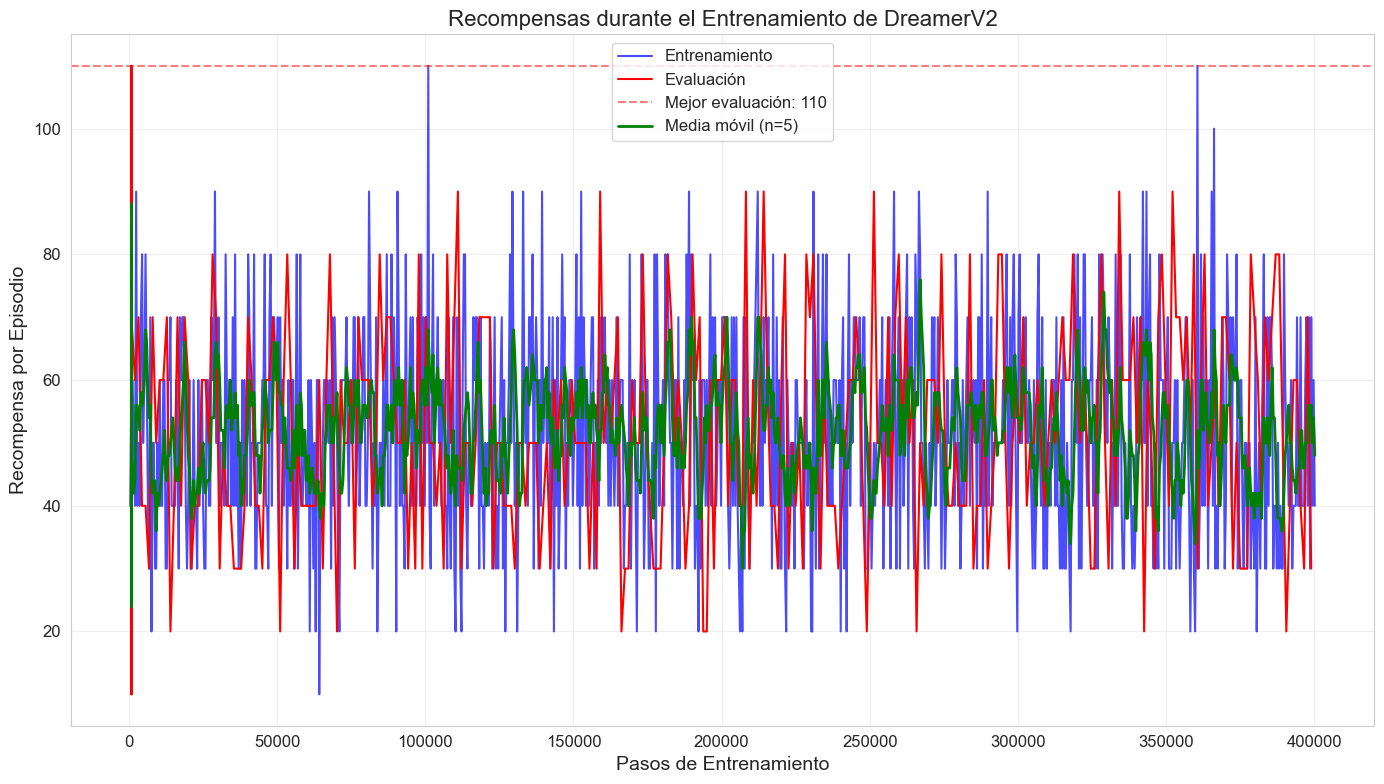


Métricas disponibles del modelo:




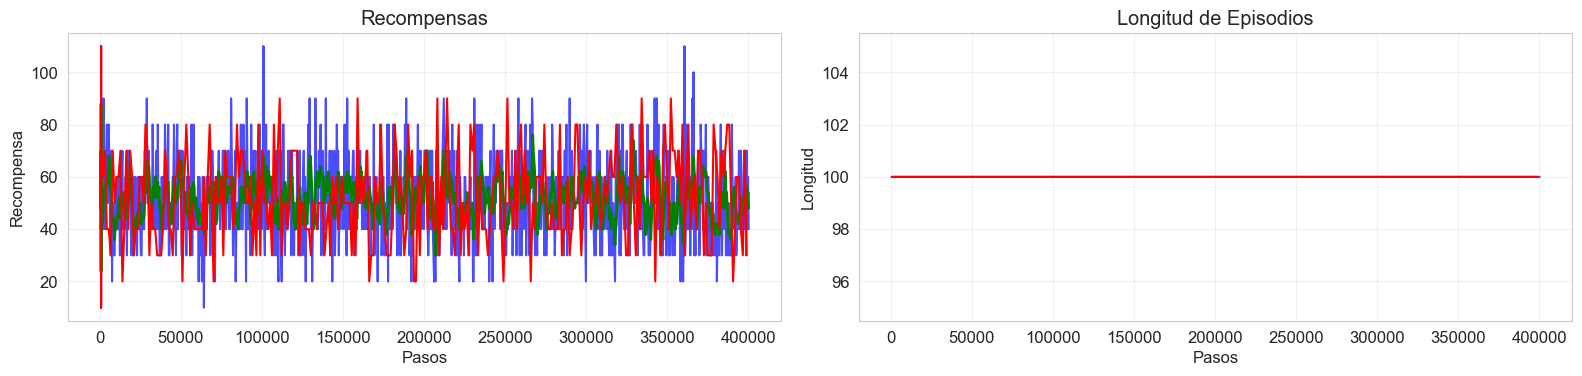

C:\Users\cuent\AppData\Local\Temp\ipykernel_27764\1977057839.py:278: RankWarning: Polyfit may be poorly conditioned
  z = np.polyfit(train_df['train_length'], train_df['train_return'], 1)
C:\Users\cuent\AppData\Roaming\Python\Python311\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\cuent\AppData\Roaming\Python\Python311\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


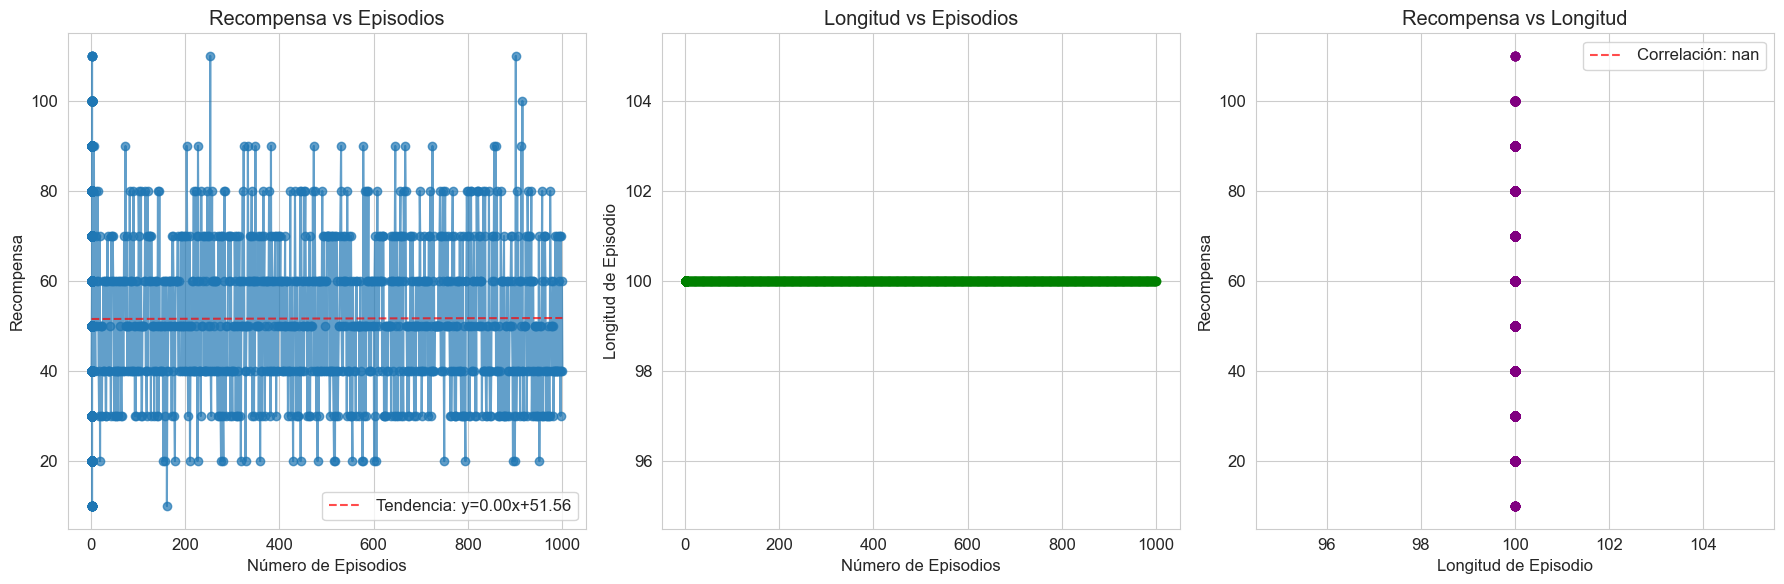

c:\Users\cuent\.conda\envs\dv2\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\cuent\.conda\envs\dv2\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\cuent\.conda\envs\dv2\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


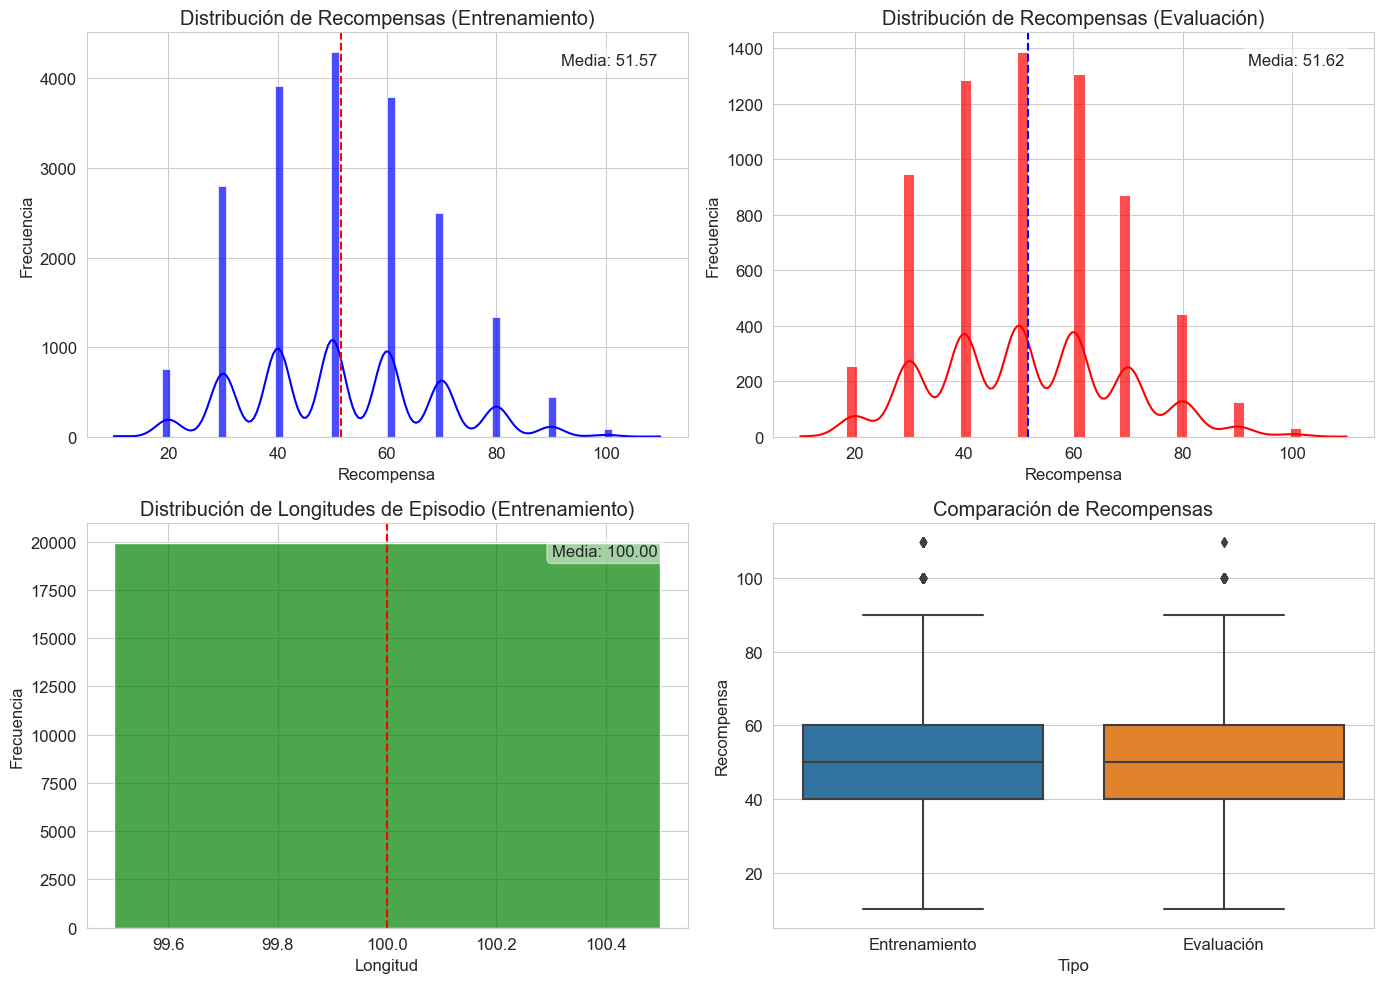

,Paso,Recompensa,Longitud,Episodio
0,360588,110.000000,100.000000,902.000000
1,792,110.000000,100.000000,2.000000
2,792,110.000000,100.000000,2.000000
3,792,110.000000,100.000000,2.000000
4,792,110.000000,100.000000,2.000000
5,792,110.000000,100.000000,2.000000
6,100988,110.000000,100.000000,253.000000
7,792,110.000000,100.000000,2.000000
8,792,100.000000,100.000000,2.000000
9,792,100.000000,100.000000,2.000000


,Paso,Recompensa,Longitud,Episodio
0,792,110.000000,100.000000,3888.000000
1,792,100.000000,100.000000,5536.000000
2,792,100.000000,100.000000,492.000000
3,792,100.000000,100.000000,3156.000000
4,792,100.000000,100.000000,1261.000000
5,792,100.000000,100.000000,4620.000000
6,792,100.000000,100.000000,5668.000000
7,792,100.000000,100.000000,1981.000000
8,792,100.000000,100.000000,1472.000000
9,792,100.000000,100.000000,3241.000000


In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.gridspec import GridSpec
from IPython.display import HTML, display
import ipywidgets as widgets

# Configuración de estilo
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 12

# Función para cargar los datos del JSONL
def load_jsonl(file_path):
    data = []
    with open(file_path, 'r') as f:
        for line in f:
            try:
                data.append(json.loads(line))
            except json.JSONDecodeError:
                continue
    return data

# Cargar datos del archivo metrics.jsonl
current_dir = os.path.dirname(os.path.abspath('__file__'))
metrics_path = os.path.join(current_dir, 'metrics.jsonl')
data = load_jsonl(metrics_path)

# Convertir a DataFrame para facilitar el análisis
df = pd.DataFrame(data)

# Separar datos de entrenamiento y evaluación
train_df = df[df['train_return'].notna()].copy()
eval_df = df[df['eval_return'].notna()].copy()

# Organizar por pasos de entrenamiento
train_df = train_df.sort_values('step')
eval_df = eval_df.sort_values('step')

# Mostrar información general del experimento
print(f"Experimento DreamerV2 - Ms. Pac-Man")
print(f"Total pasos de entrenamiento: {train_df['step'].max()}")
print(f"Total episodios de entrenamiento: {train_df['train_total_episodes'].max()}")
print(f"Recompensa media en entrenamiento: {train_df['train_return'].mean():.2f}")
if not eval_df.empty:
    print(f"Episodios de evaluación: {eval_df['eval_total_episodes'].max()}")
    print(f"Recompensa media en evaluación: {eval_df['eval_return'].mean():.2f}")
    print(f"Mejor recompensa en evaluación: {eval_df['eval_return'].max():.2f}")

# Visualización 1: Recompensas a lo largo del entrenamiento
fig, ax = plt.subplots(figsize=(14, 8))

# Graficar recompensas de entrenamiento
ax.plot(train_df['step'], train_df['train_return'], 'b-', alpha=0.7, label='Entrenamiento')

# Graficar recompensas de evaluación si existen
if not eval_df.empty:
    ax.plot(eval_df['step'], eval_df['eval_return'], 'r-', label='Evaluación')
    
    # Añadir línea de la mejor recompensa de evaluación
    best_reward = eval_df['eval_return'].max()
    ax.axhline(y=best_reward, color='r', linestyle='--', alpha=0.5, 
               label=f'Mejor evaluación: {best_reward:.0f}')

# Media móvil para suavizar las recompensas de entrenamiento
window_size = 5
if len(train_df) >= window_size:
    train_df['smooth_return'] = train_df['train_return'].rolling(window=window_size).mean()
    ax.plot(train_df['step'], train_df['smooth_return'], 'g-', linewidth=2, 
            label=f'Media móvil (n={window_size})')

ax.set_title('Recompensas durante el Entrenamiento de DreamerV2', fontsize=16)
ax.set_xlabel('Pasos de Entrenamiento', fontsize=14)
ax.set_ylabel('Recompensa por Episodio', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Visualización 2: Dashboard completo de métricas
# Verificar las columnas disponibles para métricas del modelo
model_metrics = [col for col in df.columns if any(x in col for x in ['loss', 'kl', 'ent', 'reward_', 'discount_', 'actor_', 'critic_'])]
print("\nMétricas disponibles del modelo:")
for i, metric in enumerate(sorted(model_metrics)):
    print(f"{i+1}. {metric}", end="\t")
    if (i+1) % 4 == 0:
        print()  # Nueva línea cada 4 métricas
print("\n")

# Crear un dashboard completo
fig = plt.figure(figsize=(16, 14))
gs = GridSpec(4, 2, figure=fig)

# 1. Recompensas
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(train_df['step'], train_df['train_return'], 'b-', alpha=0.7)
if 'smooth_return' in train_df:
    ax1.plot(train_df['step'], train_df['smooth_return'], 'g-', linewidth=2)
if not eval_df.empty:
    ax1.plot(eval_df['step'], eval_df['eval_return'], 'r-')
ax1.set_title('Recompensas')
ax1.set_xlabel('Pasos')
ax1.set_ylabel('Recompensa')
ax1.grid(True, alpha=0.3)

# 2. Longitudes de episodio
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(train_df['step'], train_df['train_length'], 'b-', alpha=0.7)
if not eval_df.empty:
    ax2.plot(eval_df['step'], eval_df['eval_length'], 'r-')
ax2.set_title('Longitud de Episodios')
ax2.set_xlabel('Pasos')
ax2.set_ylabel('Longitud')
ax2.grid(True, alpha=0.3)

# 3. Pérdidas del modelo (si existen)
if 'model_loss' in df.columns:
    model_df = df[df['model_loss'].notna()].sort_values('step')
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.semilogy(model_df['step'], model_df['model_loss'], 'b-')
    ax3.set_title('Model Loss')
    ax3.set_xlabel('Pasos')
    ax3.set_ylabel('Log Loss')
    ax3.grid(True, alpha=0.3)

# 4. KL Divergence (si existe)
if 'kl_loss' in df.columns:
    kl_df = df[df['kl_loss'].notna()].sort_values('step')
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.plot(kl_df['step'], kl_df['kl_loss'], 'm-')
    ax4.set_title('KL Divergence')
    ax4.set_xlabel('Pasos')
    ax4.set_ylabel('KL Loss')
    ax4.grid(True, alpha=0.3)

# 5. Actor y Critic Loss (si existen)
if 'actor_loss' in df.columns and 'critic_loss' in df.columns:
    ac_df = df[(df['actor_loss'].notna()) & (df['critic_loss'].notna())].sort_values('step')
    ax5 = fig.add_subplot(gs[2, 0])
    ax5.plot(ac_df['step'], ac_df['actor_loss'], 'g-', label='Actor Loss')
    ax5.plot(ac_df['step'], ac_df['critic_loss'], 'r-', label='Critic Loss')
    ax5.set_title('Actor y Critic Loss')
    ax5.set_xlabel('Pasos')
    ax5.set_ylabel('Loss')
    ax5.legend()
    ax5.grid(True, alpha=0.3)

# 6. Actor Entropy (si existe)
if 'actor_ent' in df.columns:
    ent_df = df[df['actor_ent'].notna()].sort_values('step')
    ax6 = fig.add_subplot(gs[2, 1])
    ax6.plot(ent_df['step'], ent_df['actor_ent'], 'c-')
    ax6.set_title('Actor Entropy')
    ax6.set_xlabel('Pasos')
    ax6.set_ylabel('Entropy')
    ax6.grid(True, alpha=0.3)

# 7. Reward y Discount Loss (si existen)
if 'reward_loss' in df.columns and 'discount_loss' in df.columns:
    rd_df = df[(df['reward_loss'].notna()) & (df['discount_loss'].notna())].sort_values('step')
    ax7 = fig.add_subplot(gs[3, 0])
    ax7.plot(rd_df['step'], rd_df['reward_loss'], 'y-', label='Reward Loss')
    ax7.plot(rd_df['step'], rd_df['discount_loss'], 'k-', label='Discount Loss')
    ax7.set_title('Reward y Discount Loss')
    ax7.set_xlabel('Pasos')
    ax7.set_ylabel('Loss')
    ax7.legend()
    ax7.grid(True, alpha=0.3)

# 8. Image Loss (si existe)
if 'image_loss' in df.columns:
    img_df = df[df['image_loss'].notna()].sort_values('step')
    ax8 = fig.add_subplot(gs[3, 1])
    ax8.semilogy(img_df['step'], img_df['image_loss'], 'b-')
    ax8.set_title('Image Reconstruction Loss')
    ax8.set_xlabel('Pasos')
    ax8.set_ylabel('Log Loss')
    ax8.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Visualización 3: Widget interactivo para explorar métricas específicas
available_metrics = sorted([col for col in df.columns if col != 'step' and not df[col].isna().all()])

def plot_selected_metric(metric):
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Filtrar valores no nulos
    metric_df = df[df[metric].notna()].sort_values('step')
    
    if len(metric_df) > 0:
        # Determinar si usar escala logarítmica
        use_log = 'loss' in metric and metric_df[metric].max() / max(1e-5, metric_df[metric].min()) > 100
        
        if use_log:
            ax.semilogy(metric_df['step'], metric_df[metric], 'b-')
        else:
            ax.plot(metric_df['step'], metric_df[metric], 'b-')
            
        # Media móvil si hay suficientes puntos
        if len(metric_df) > 5:
            metric_df['smooth'] = metric_df[metric].rolling(window=5).mean()
            ax.plot(metric_df['step'], metric_df['smooth'], 'r-', linewidth=2, label='Media móvil (n=5)')
            ax.legend()
        
        ax.set_title(f'Métrica: {metric}')
        ax.set_xlabel('Pasos de Entrenamiento')
        ax.set_ylabel(metric)
        ax.grid(True, alpha=0.3)
        
        # Estadísticas básicas
        mean_val = metric_df[metric].mean()
        std_val = metric_df[metric].std()
        min_val = metric_df[metric].min()
        max_val = metric_df[metric].max()
        
        # Mostrar estadísticas en el gráfico
        stats_text = f"Media: {mean_val:.4f}\nDesv. Est.: {std_val:.4f}\nMin: {min_val:.4f}\nMax: {max_val:.4f}"
        ax.text(0.02, 0.95, stats_text, transform=ax.transAxes, 
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
        
        plt.tight_layout()
        plt.show()
    else:
        print(f"No hay datos disponibles para la métrica {metric}")

# Crear widget para selección de métrica
metric_dropdown = widgets.Dropdown(
    options=available_metrics,
    value=available_metrics[0] if available_metrics else None,
    description='Métrica:',
    style={'description_width': 'initial'},
    layout={'width': '50%'}
)

# Mostrar widget
output = widgets.interactive_output(plot_selected_metric, {'metric': metric_dropdown})
display(widgets.VBox([metric_dropdown, output]))

# Visualización 4: Progreso de entrenamiento con estadísticas
# Crear gráfico de progresión de entrenamiento con líneas de tendencia
if len(train_df) > 0:
    fig, axs = plt.subplots(1, 3, figsize=(18, 6))
    
    # 1. Recompensa vs Episodios
    axs[0].plot(train_df['train_total_episodes'], train_df['train_return'], 'o-', alpha=0.7)
    axs[0].set_title('Recompensa vs Episodios')
    axs[0].set_xlabel('Número de Episodios')
    axs[0].set_ylabel('Recompensa')
    
    # Línea de tendencia
    if len(train_df) > 2:
        z = np.polyfit(train_df['train_total_episodes'], train_df['train_return'], 1)
        p = np.poly1d(z)
        axs[0].plot(train_df['train_total_episodes'], p(train_df['train_total_episodes']), 
                   "r--", alpha=0.7, label=f'Tendencia: y={z[0]:.2f}x+{z[1]:.2f}')
        axs[0].legend()
    
    # 2. Longitud vs Episodios
    axs[1].plot(train_df['train_total_episodes'], train_df['train_length'], 'o-', alpha=0.7, color='green')
    axs[1].set_title('Longitud vs Episodios')
    axs[1].set_xlabel('Número de Episodios')
    axs[1].set_ylabel('Longitud de Episodio')
    
    # 3. Recompensa vs Longitud (scatter)
    axs[2].scatter(train_df['train_length'], train_df['train_return'], alpha=0.7, color='purple')
    axs[2].set_title('Recompensa vs Longitud')
    axs[2].set_xlabel('Longitud de Episodio')
    axs[2].set_ylabel('Recompensa')
    
    # Línea de regresión
    if len(train_df) > 2:
        z = np.polyfit(train_df['train_length'], train_df['train_return'], 1)
        p = np.poly1d(z)
        axs[2].plot(sorted(train_df['train_length']), p(sorted(train_df['train_length'])), 
                   "r--", alpha=0.7, label=f'Correlación: {np.corrcoef(train_df["train_length"], train_df["train_return"])[0,1]:.2f}')
        axs[2].legend()
    
    plt.tight_layout()
    plt.show()

# Visualización 5: Histogramas y distribuciones
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribución de recompensas de entrenamiento
sns.histplot(train_df['train_return'], kde=True, ax=axs[0, 0], color='blue', alpha=0.7)
axs[0, 0].axvline(train_df['train_return'].mean(), color='r', linestyle='--')
axs[0, 0].set_title('Distribución de Recompensas (Entrenamiento)')
axs[0, 0].set_xlabel('Recompensa')
axs[0, 0].set_ylabel('Frecuencia')
axs[0, 0].text(0.95, 0.95, f'Media: {train_df["train_return"].mean():.2f}', 
              transform=axs[0, 0].transAxes, ha='right', va='top',
              bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

# 2. Distribución de recompensas de evaluación (si existen)
if not eval_df.empty:
    sns.histplot(eval_df['eval_return'], kde=True, ax=axs[0, 1], color='red', alpha=0.7)
    axs[0, 1].axvline(eval_df['eval_return'].mean(), color='blue', linestyle='--')
    axs[0, 1].set_title('Distribución de Recompensas (Evaluación)')
    axs[0, 1].set_xlabel('Recompensa')
    axs[0, 1].set_ylabel('Frecuencia')
    axs[0, 1].text(0.95, 0.95, f'Media: {eval_df["eval_return"].mean():.2f}', 
                  transform=axs[0, 1].transAxes, ha='right', va='top',
                  bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
else:
    axs[0, 1].set_title('No hay datos de evaluación disponibles')
    axs[0, 1].axis('off')

# 3. Distribución de longitudes de episodio (entrenamiento)
sns.histplot(train_df['train_length'], kde=True, ax=axs[1, 0], color='green', alpha=0.7)
axs[1, 0].axvline(train_df['train_length'].mean(), color='r', linestyle='--')
axs[1, 0].set_title('Distribución de Longitudes de Episodio (Entrenamiento)')
axs[1, 0].set_xlabel('Longitud')
axs[1, 0].set_ylabel('Frecuencia')
axs[1, 0].text(0.95, 0.95, f'Media: {train_df["train_length"].mean():.2f}', 
              transform=axs[1, 0].transAxes, ha='right', va='top',
              bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

# 4. Boxplot comparativo (si hay datos de evaluación)
if not eval_df.empty:
    # Preparar datos para boxplot - crear un dataframe con formato largo
    box_data_train = pd.DataFrame({
        'Recompensa': train_df['train_return'],
        'Tipo': 'Entrenamiento'
    })
    box_data_eval = pd.DataFrame({
        'Recompensa': eval_df['eval_return'],
        'Tipo': 'Evaluación'
    })
    box_data_df = pd.concat([box_data_train, box_data_eval])
    # Usar el formato correcto para seaborn
    sns.boxplot(x='Tipo', y='Recompensa', data=box_data_df, ax=axs[1, 1])
    axs[1, 1].set_title('Comparación de Recompensas')
    axs[1, 1].set_ylabel('Recompensa')
else:
    # Scatterplot de recompensa vs pasos en lugar del boxplot
    sns.regplot(x='step', y='train_return', data=train_df, ax=axs[1, 1], scatter_kws={'alpha':0.6})
    axs[1, 1].set_title('Tendencia de Recompensas')
    axs[1, 1].set_xlabel('Pasos')
    axs[1, 1].set_ylabel('Recompensa')

plt.tight_layout()
plt.show()

# Visualización 6: Tabla resumen de las mejores recompensas
if len(train_df) > 0:
    # Ordenar por recompensa
    best_train = train_df.sort_values('train_return', ascending=False).head(10)
    best_train_styled = best_train[['step', 'train_return', 'train_length', 'train_total_episodes']].reset_index(drop=True)
    best_train_styled.columns = ['Paso', 'Recompensa', 'Longitud', 'Episodio']
    
    display(HTML("<h3>Top 10 Mejores Episodios de Entrenamiento</h3>"))
    display(best_train_styled.style.highlight_max(color='lightgreen').highlight_min(color='lightpink'))
    
    if not eval_df.empty:
        best_eval = eval_df.sort_values('eval_return', ascending=False).head(10)
        best_eval_styled = best_eval[['step', 'eval_return', 'eval_length', 'eval_total_episodes']].reset_index(drop=True)
        best_eval_styled.columns = ['Paso', 'Recompensa', 'Longitud', 'Episodio']
        
        display(HTML("<h3>Top 10 Mejores Episodios de Evaluación</h3>"))
        display(best_eval_styled.style.highlight_max(color='lightgreen').highlight_min(color='lightpink'))

# Visualización 7: Estadísticas finales y resumen
total_steps = train_df

Datos cargados exitosamente desde atari-dreamerv2.json
Tipo de datos: <class 'list'>
Número de elementos: 605

Estructura del primer elemento:
  - task: <class 'str'>
  - method: <class 'str'>
  - seed: <class 'str'>
  - xs: <class 'list'>
    Longitud: 199
    Primeros 5 valores: [1000000.0, 2000000.0, 3000000.0, 4000000.0, 5000000.0]
  - ys: <class 'list'>
    Longitud: 199
    Primeros 5 valores: [431.0, 859.0, 1575.0, 1871.0, 1245.0]

Tareas encontradas: {'atari_fishing_derby', 'atari_tutankham', 'atari_phoenix', 'atari_solaris', 'atari_time_pilot', 'atari_crazy_climber', 'atari_boxing', 'atari_bowling', 'atari_gopher', 'atari_chopper_command', 'atari_james_bond', 'atari_battle_zone', 'atari_montezuma_revenge', 'atari_up_n_down', 'atari_kangaroo', 'atari_yars_revenge', 'atari_video_pinball', 'atari_kung_fu_master', 'atari_space_invaders', 'atari_double_dunk', 'atari_wizard_of_wor', 'atari_tennis', 'atari_alien', 'atari_amidar', 'atari_venture', 'atari_frostbite', 'atari_berzerk', '

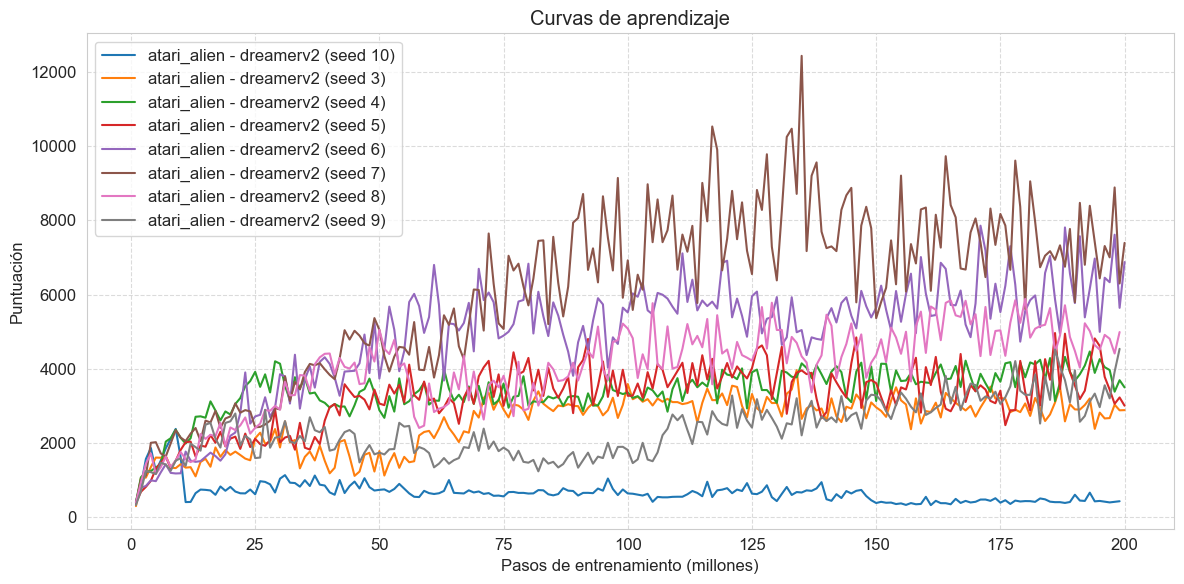


Calculando estadísticas...
Estadísticas generales:
          max_score   final_score     mean_score      std_score
count  6.050000e+02  6.050000e+02     605.000000     605.000000
mean   6.969798e+04  5.445434e+04   45585.902957   13407.941466
std    1.747017e+05  1.567770e+05  144453.453204   33738.296640
min   -9.652800e+03 -1.058080e+04  -11270.599214       0.000000
25%    4.079000e+02  2.107000e+02     167.089995      87.012488
50%    6.690000e+03  4.669231e+03    4194.244137    1464.711616
75%    5.345000e+04  2.941667e+04   25323.718333   10540.250594
max    1.040850e+06  1.014230e+06  992589.189127  345602.852361

Generando gráficas de distribución de puntuaciones...


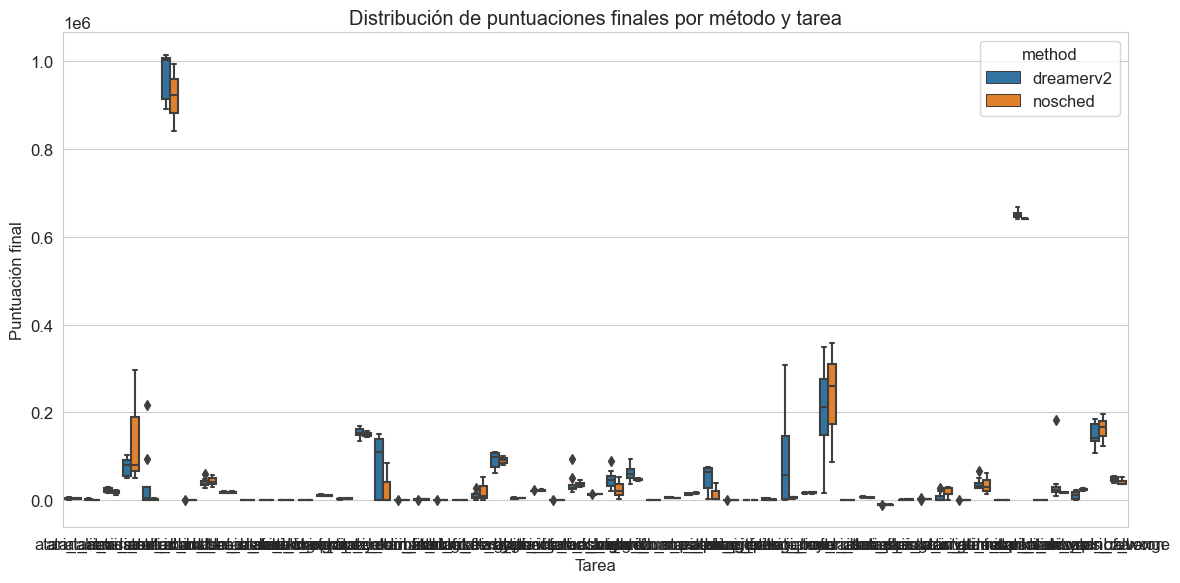

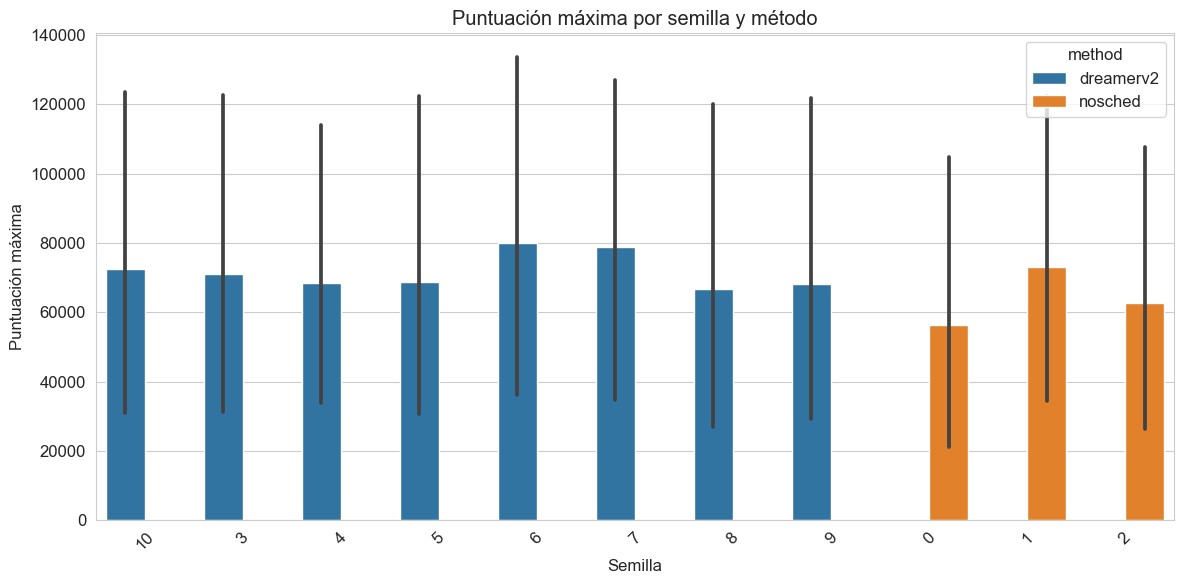

In [2]:
import json
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import seaborn as sns

# Asumiendo que tienes los datos en un archivo llamado 'data.json'
def load_data(filename='data.json'):
    try:
        with open(filename, 'r') as f:
            data = json.load(f)
        print(f"Datos cargados exitosamente desde {filename}")
        return data
    except FileNotFoundError:
        print(f"Archivo {filename} no encontrado.")
        return None
    except json.JSONDecodeError:
        print(f"Error al decodificar JSON desde {filename}.")
        return None

def explore_data_structure(data):
    """Explora la estructura básica de los datos"""
    print(f"Tipo de datos: {type(data)}")
    print(f"Número de elementos: {len(data)}")
    
    if isinstance(data, list) and len(data) > 0:
        print("\nEstructura del primer elemento:")
        for key, value in data[0].items():
            print(f"  - {key}: {type(value)}")
            if isinstance(value, list):
                print(f"    Longitud: {len(value)}")
                print(f"    Primeros 5 valores: {value[:5]}")
    
    # Extraer información sobre tasks, methods y seeds
    tasks = set()
    methods = set()
    seeds = set()
    
    for item in data:
        if 'task' in item:
            tasks.add(item['task'])
        if 'method' in item:
            methods.add(item['method'])
        if 'seed' in item:
            seeds.add(item['seed'])
    
    print(f"\nTareas encontradas: {tasks}")
    print(f"Métodos encontrados: {methods}")
    print(f"Semillas encontradas: {seeds}")

def plot_learning_curves(data, task_filter=None, method_filter=None):
    """Grafica las curvas de aprendizaje para los datos filtrados"""
    filtered_data = data
    if task_filter:
        filtered_data = [d for d in filtered_data if d['task'] == task_filter]
    if method_filter:
        filtered_data = [d for d in filtered_data if d['method'] == method_filter]
    
    plt.figure(figsize=(12, 6))
    
    for item in filtered_data:
        task = item['task']
        method = item['method']
        seed = item['seed']
        xs = item['xs']
        ys = item['ys']
        
        # Convertir pasos a millones para mejor legibilidad
        xs_millions = [x/1e6 for x in xs]
        
        plt.plot(xs_millions, ys, label=f"{task} - {method} (seed {seed})")
    
    plt.xlabel('Pasos de entrenamiento (millones)')
    plt.ylabel('Puntuación')
    plt.title('Curvas de aprendizaje')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

def calculate_statistics(data, task_filter=None, method_filter=None):
    """Calcula estadísticas para los datos filtrados"""
    filtered_data = data
    if task_filter:
        filtered_data = [d for d in filtered_data if d['task'] == task_filter]
    if method_filter:
        filtered_data = [d for d in filtered_data if d['method'] == method_filter]
    
    # Crear un DataFrame para facilitar el análisis
    results = []
    for item in filtered_data:
        task = item['task']
        method = item['method']
        seed = item['seed']
        ys = item['ys']
        
        results.append({
            'task': task,
            'method': method,
            'seed': seed,
            'max_score': max(ys),
            'final_score': ys[-1],
            'mean_score': np.mean(ys),
            'std_score': np.std(ys)
        })
    
    df = pd.DataFrame(results)
    
    print("Estadísticas generales:")
    print(df.describe())
    
    return df

def plot_score_distribution(data_df):
    """Grafica la distribución de puntuaciones finales por método y semilla"""
    if data_df is None or len(data_df) == 0:
        print("No hay datos para graficar")
        return
    
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='task', y='final_score', hue='method', data=data_df)
    plt.title('Distribución de puntuaciones finales por método y tarea')
    plt.xlabel('Tarea')
    plt.ylabel('Puntuación final')
    plt.tight_layout()
    plt.show()
    
    # Gráfico de barras para comparar rendimiento máximo
    plt.figure(figsize=(12, 6))
    sns.barplot(x='seed', y='max_score', hue='method', data=data_df)
    plt.title('Puntuación máxima por semilla y método')
    plt.xlabel('Semilla')
    plt.ylabel('Puntuación máxima')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Función principal
def main(filename='data.json'):
    # Cargar los datos
    data = load_data(filename)
    if data is None:
        return
    
    # Explorar la estructura de los datos
    explore_data_structure(data)
    
    # Graficar curvas de aprendizaje
    print("\nGenerando gráficas de curvas de aprendizaje...")
    plot_learning_curves(data, task_filter='atari_alien', method_filter='dreamerv2')
    
    # Calcular estadísticas
    print("\nCalculando estadísticas...")
    stats_df = calculate_statistics(data)
    
    # Visualizar distribución de puntuaciones
    print("\nGenerando gráficas de distribución de puntuaciones...")
    plot_score_distribution(stats_df)

# Ejecutar si se llama directamente
if __name__ == "__main__":
    # Cambia 'data.json' por el nombre de tu archivo
    main('atari-dreamerv2.json')

Encontrados 11 experimentos para MS Pacman

Estadísticas por método:
      method   mean_score    std_score  min_score  max_score
0  dreamerv2  4886.379453  1533.847611      479.0     9196.3
1    nosched  4765.256783  1423.789474      564.0     7822.1

Estadísticas por método y semilla:
      method seed   mean_score    std_score   min_score  max_score  \
0  dreamerv2   10  5419.034841  1359.234946  845.000000     7707.0   
1  dreamerv2    3  4303.010000   927.286494  677.000000     5594.0   
2  dreamerv2    4  3912.645175  1051.902874  479.000000     5914.0   
3  dreamerv2    5  6209.537530  1468.387184  727.000000     8156.1   
4  dreamerv2    6  5243.049167  1085.429872  606.000000     6343.0   
5  dreamerv2    7  4471.895152   858.209433  720.000000     5733.0   
6  dreamerv2    8  6042.365905  1815.744953  485.454545     9196.3   
7  dreamerv2    9  3490.963987   891.498655  644.000000     5048.0   
8    nosched    0  4894.800348  1404.372752  596.000000     7260.0   
9    nosched

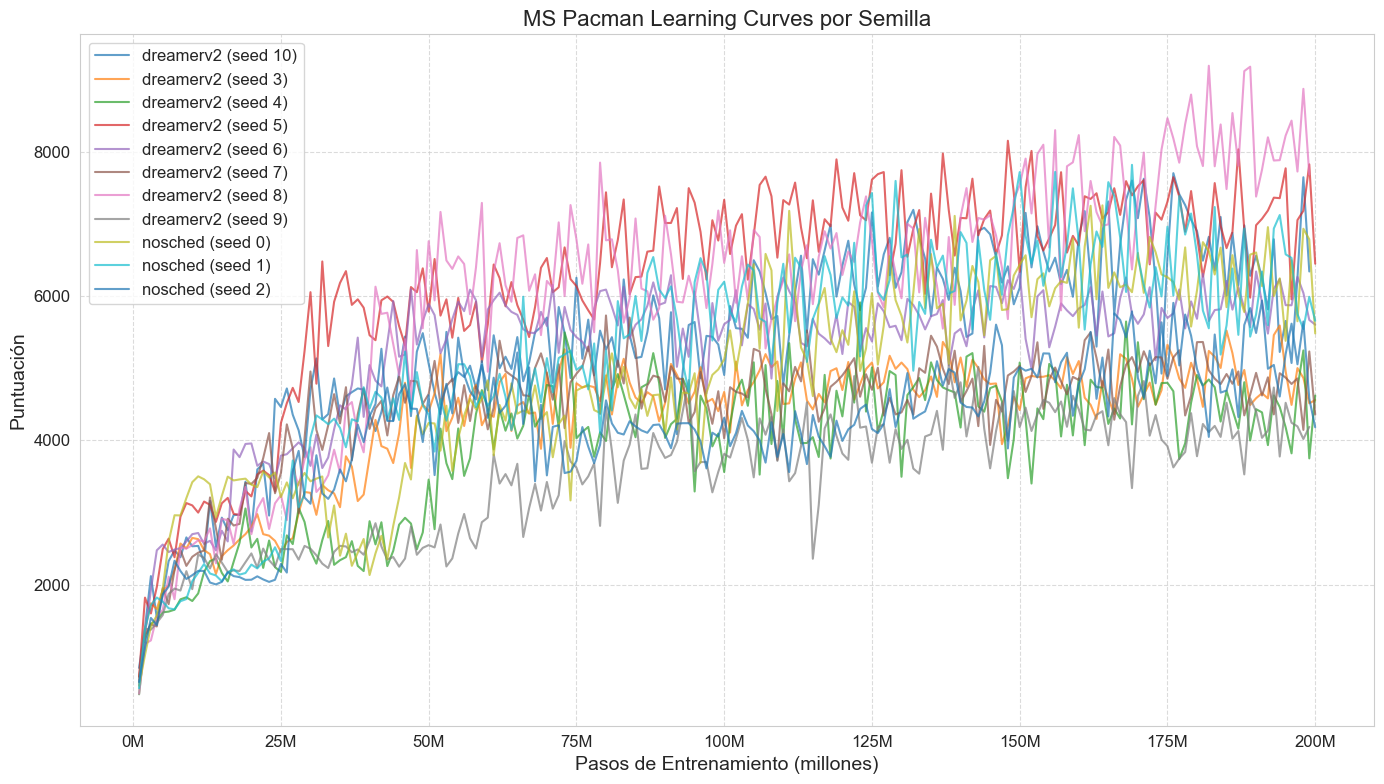

C:\Users\cuent\AppData\Local\Temp\ipykernel_27764\2188695813.py:88: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.lineplot(
c:\Users\cuent\.conda\envs\dv2\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\cuent\.conda\envs\dv2\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\cuent\.conda\envs\dv2\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
 

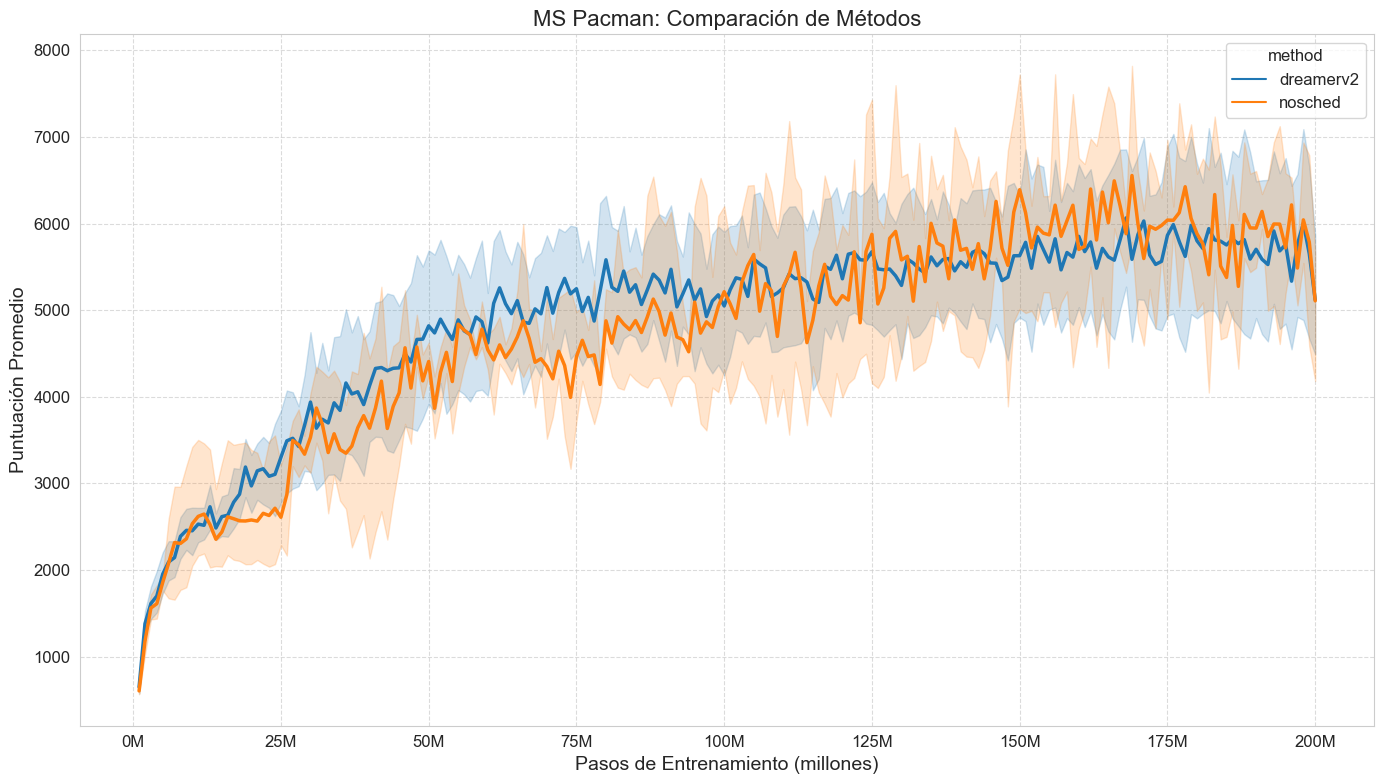

c:\Users\cuent\.conda\envs\dv2\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\cuent\.conda\envs\dv2\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\cuent\.conda\envs\dv2\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


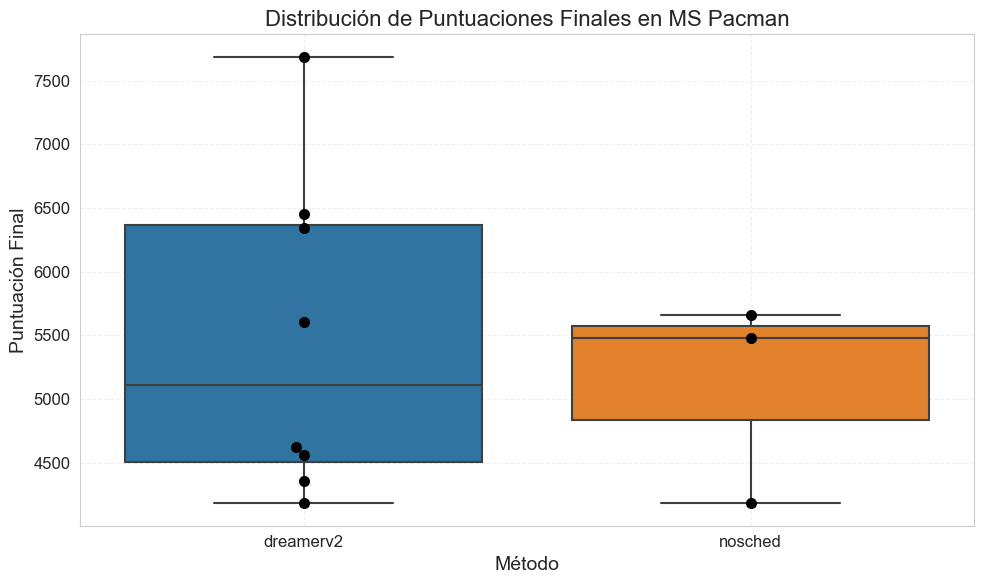

C:\Users\cuent\AppData\Local\Temp\ipykernel_27764\2188695813.py:136: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.lineplot(
c:\Users\cuent\.conda\envs\dv2\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\cuent\.conda\envs\dv2\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\cuent\.conda\envs\dv2\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.


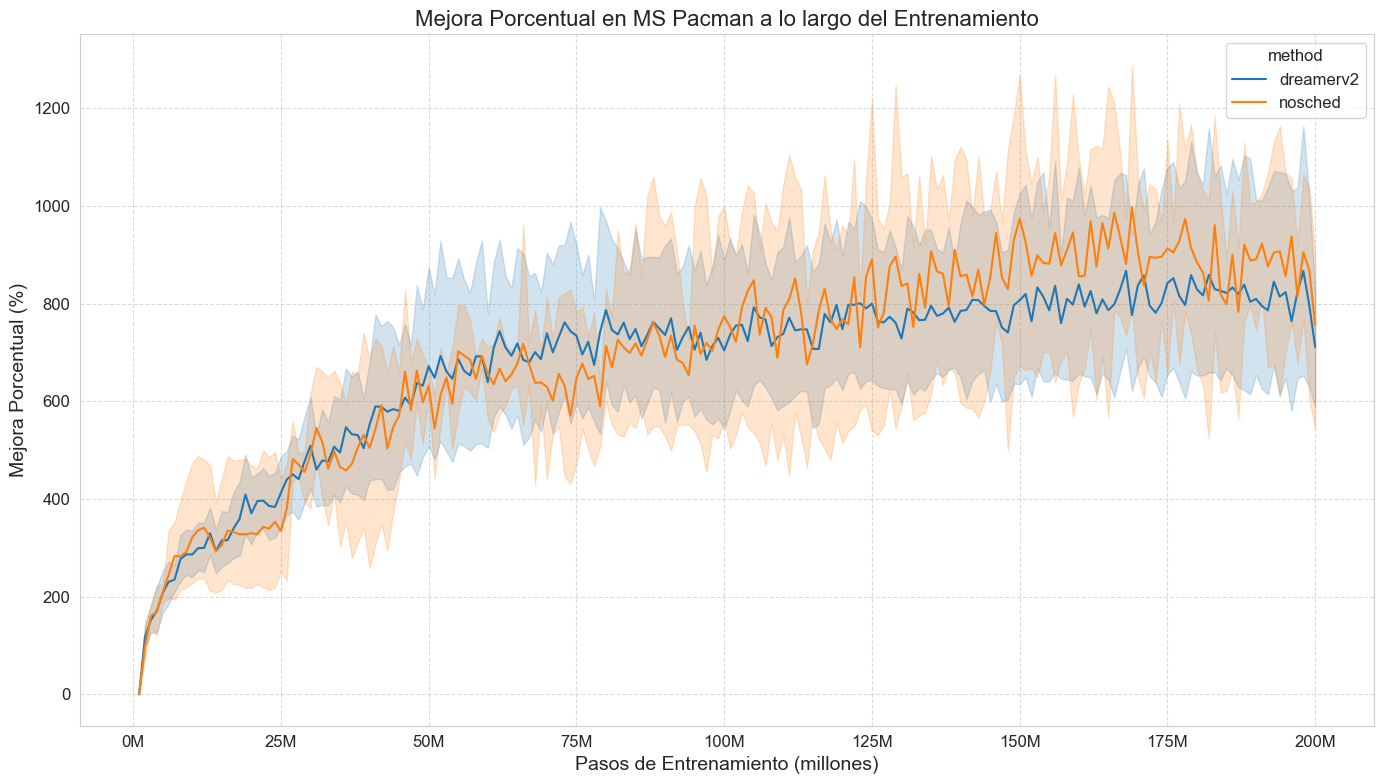


Métricas de rendimiento para MS Pacman:
Máxima puntuación alcanzada: 9196.3
Puntuación media global: 4853.30
Desviación estándar global: 1505.24

Análisis de convergencia (% de puntuación máxima alcanzada al final):
method
dreamerv2    81.502534
nosched      72.766082
Name: convergence_pct, dtype: float64


<Figure size 1200x800 with 0 Axes>

In [3]:
import json
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib.ticker import StrMethodFormatter

# Cargar datos y filtrar para MS Pacman
def explore_ms_pacman(file_path='atari-dreamerv2.json'):
    with open(file_path, 'r') as f:
        data = json.load(f)
    
    # Filtrar solo para MS Pacman
    ms_pacman_data = [item for item in data if item['task'] == 'atari_ms_pacman']
    
    print(f"Encontrados {len(ms_pacman_data)} experimentos para MS Pacman")
    
    # Crear un DataFrame para análisis más fácil
    experiments = []
    for item in ms_pacman_data:
        method = item['method']
        seed = item['seed']
        xs = item['xs']
        ys = item['ys']
        
        # Convertir listas en un DataFrame
        exp_df = pd.DataFrame({
            'step': xs,
            'score': ys,
            'method': method,
            'seed': seed
        })
        experiments.append(exp_df)
    
    all_experiments = pd.concat(experiments, ignore_index=True)
    return all_experiments, ms_pacman_data

# Función para estadísticas
def calculate_ms_pacman_stats(df):
    # Agrupar por método y semilla
    stats = df.groupby(['method', 'seed']).agg({
        'score': ['mean', 'std', 'min', 'max', 'last']
    }).reset_index()
    
    stats.columns = ['method', 'seed', 'mean_score', 'std_score', 'min_score', 'max_score', 'final_score']
    
    # Calcular estadísticas adicionales por método
    method_stats = df.groupby(['method']).agg({
        'score': ['mean', 'std', 'min', 'max']
    }).reset_index()
    
    method_stats.columns = ['method', 'mean_score', 'std_score', 'min_score', 'max_score']
    
    return stats, method_stats

# Visualización 1: Learning curves por semilla
def plot_learning_curves(data):
    plt.figure(figsize=(14, 8))
    
    # Agrupar por método y semilla
    for item in data:
        method = item['method']
        seed = item['seed']
        xs = [x/1e6 for x in item['xs']]  # Convertir a millones
        ys = item['ys']
        
        plt.plot(xs, ys, label=f"{method} (seed {seed})", alpha=0.7)
    
    plt.title('MS Pacman Learning Curves por Semilla', fontsize=16)
    plt.xlabel('Pasos de Entrenamiento (millones)', fontsize=14)
    plt.ylabel('Puntuación', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=12)
    
    # Mejorar formato del eje X
    plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:.0f}M'))
    
    return plt

# Visualización 2: Promedio por método con intervalo de confianza
def plot_method_comparison(df):
    plt.figure(figsize=(14, 8))
    
    # Convertir steps a millones para mejor visualización
    df['step_millions'] = df['step'] / 1e6
    
    # Crear gráfico con seaborn
    sns.lineplot(
        data=df, 
        x='step_millions', 
        y='score', 
        hue='method',
        ci=95,  # Intervalo de confianza del 95%
        linewidth=2.5
    )
    
    plt.title('MS Pacman: Comparación de Métodos', fontsize=16)
    plt.xlabel('Pasos de Entrenamiento (millones)', fontsize=14)
    plt.ylabel('Puntuación Promedio', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Mejorar formato del eje X
    plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:.0f}M'))
    
    return plt

# Visualización 3: Distribución de puntuaciones finales
def plot_final_scores(df):
    # Obtener la última puntuación para cada experimento
    final_scores = df.groupby(['method', 'seed']).last().reset_index()
    
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='method', y='score', data=final_scores)
    sns.swarmplot(x='method', y='score', data=final_scores, color='black', size=8)
    
    plt.title('Distribución de Puntuaciones Finales en MS Pacman', fontsize=16)
    plt.xlabel('Método', fontsize=14)
    plt.ylabel('Puntuación Final', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.3)
    
    return plt

# Visualización 4: Progreso de aprendizaje a lo largo del tiempo
def plot_learning_progress(df):
    # Convertir steps a millones
    df['step_millions'] = df['step'] / 1e6
    
    # Calcular la mejora porcentual respecto a las puntuaciones iniciales
    baseline = df[df['step'] == df['step'].min()].groupby(['method', 'seed'])['score'].mean().reset_index()
    baseline.columns = ['method', 'seed', 'baseline_score']
    
    df_with_baseline = pd.merge(df, baseline, on=['method', 'seed'], how='left')
    df_with_baseline['improvement'] = ((df_with_baseline['score'] / df_with_baseline['baseline_score']) - 1) * 100
    
    plt.figure(figsize=(14, 8))
    sns.lineplot(
        data=df_with_baseline,
        x='step_millions',
        y='improvement',
        hue='method',
        ci=95
    )
    
    plt.title('Mejora Porcentual en MS Pacman a lo largo del Entrenamiento', fontsize=16)
    plt.xlabel('Pasos de Entrenamiento (millones)', fontsize=14)
    plt.ylabel('Mejora Porcentual (%)', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Mejorar formato del eje X
    plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:.0f}M'))
    
    return plt

# Ejecutar todo el análisis
ms_pacman_df, ms_pacman_raw = explore_ms_pacman('atari-dreamerv2.json')
stats, method_stats = calculate_ms_pacman_stats(ms_pacman_df)

print("\nEstadísticas por método:")
print(method_stats)

print("\nEstadísticas por método y semilla:")
print(stats.head(10))  # Mostrar las primeras 10 filas

# Visualizaciones
fig1 = plot_learning_curves(ms_pacman_raw)
fig1.tight_layout()
fig1.show()

fig2 = plot_method_comparison(ms_pacman_df)
fig2.tight_layout()
fig2.show()

fig3 = plot_final_scores(ms_pacman_df)
fig3.tight_layout()
fig3.show()

fig4 = plot_learning_progress(ms_pacman_df)
fig4.tight_layout()
fig4.show()

# Guardar visualizaciones (opcional)
fig1.savefig('ms_pacman_learning_curves.png', dpi=300)
fig2.savefig('ms_pacman_method_comparison.png', dpi=300)
fig3.savefig('ms_pacman_final_scores.png', dpi=300)
fig4.savefig('ms_pacman_learning_progress.png', dpi=300)

# Métricas adicionales
print("\nMétricas de rendimiento para MS Pacman:")
print(f"Máxima puntuación alcanzada: {ms_pacman_df['score'].max()}")
print(f"Puntuación media global: {ms_pacman_df['score'].mean():.2f}")
print(f"Desviación estándar global: {ms_pacman_df['score'].std():.2f}")

# Análisis de convergencia - diferencia entre max y último valor
convergence_analysis = stats.copy()
convergence_analysis['convergence_gap'] = convergence_analysis['max_score'] - convergence_analysis['final_score']
convergence_analysis['convergence_pct'] = (convergence_analysis['final_score'] / convergence_analysis['max_score']) * 100

print("\nAnálisis de convergencia (% de puntuación máxima alcanzada al final):")
print(convergence_analysis.groupby('method')['convergence_pct'].mean())


Comparativa de rendimiento limitada a 200k pasos:
--------------------------------------------------
Pasos analizados: 199788
Episodios completados: 500.0
Recompensa media en entrenamiento: 51.57
Mejor recompensa en entrenamiento: 110.00
Episodios de evaluación: 6321.0
Recompensa media en evaluación: 51.56
Mejor recompensa en evaluación: 110.00


c:\Users\cuent\.conda\envs\dv2\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\cuent\AppData\Local\Temp\ipykernel_27764\1079853810.py:68: RankWarning: Polyfit may be poorly conditioned
  z = np.polyfit(train_df_limited['train_length'], train_df_limited['train_return'], 1)
C:\Users\cuent\AppData\Roaming\Python\Python311\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\cuent\AppData\Roaming\Python\Python311\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


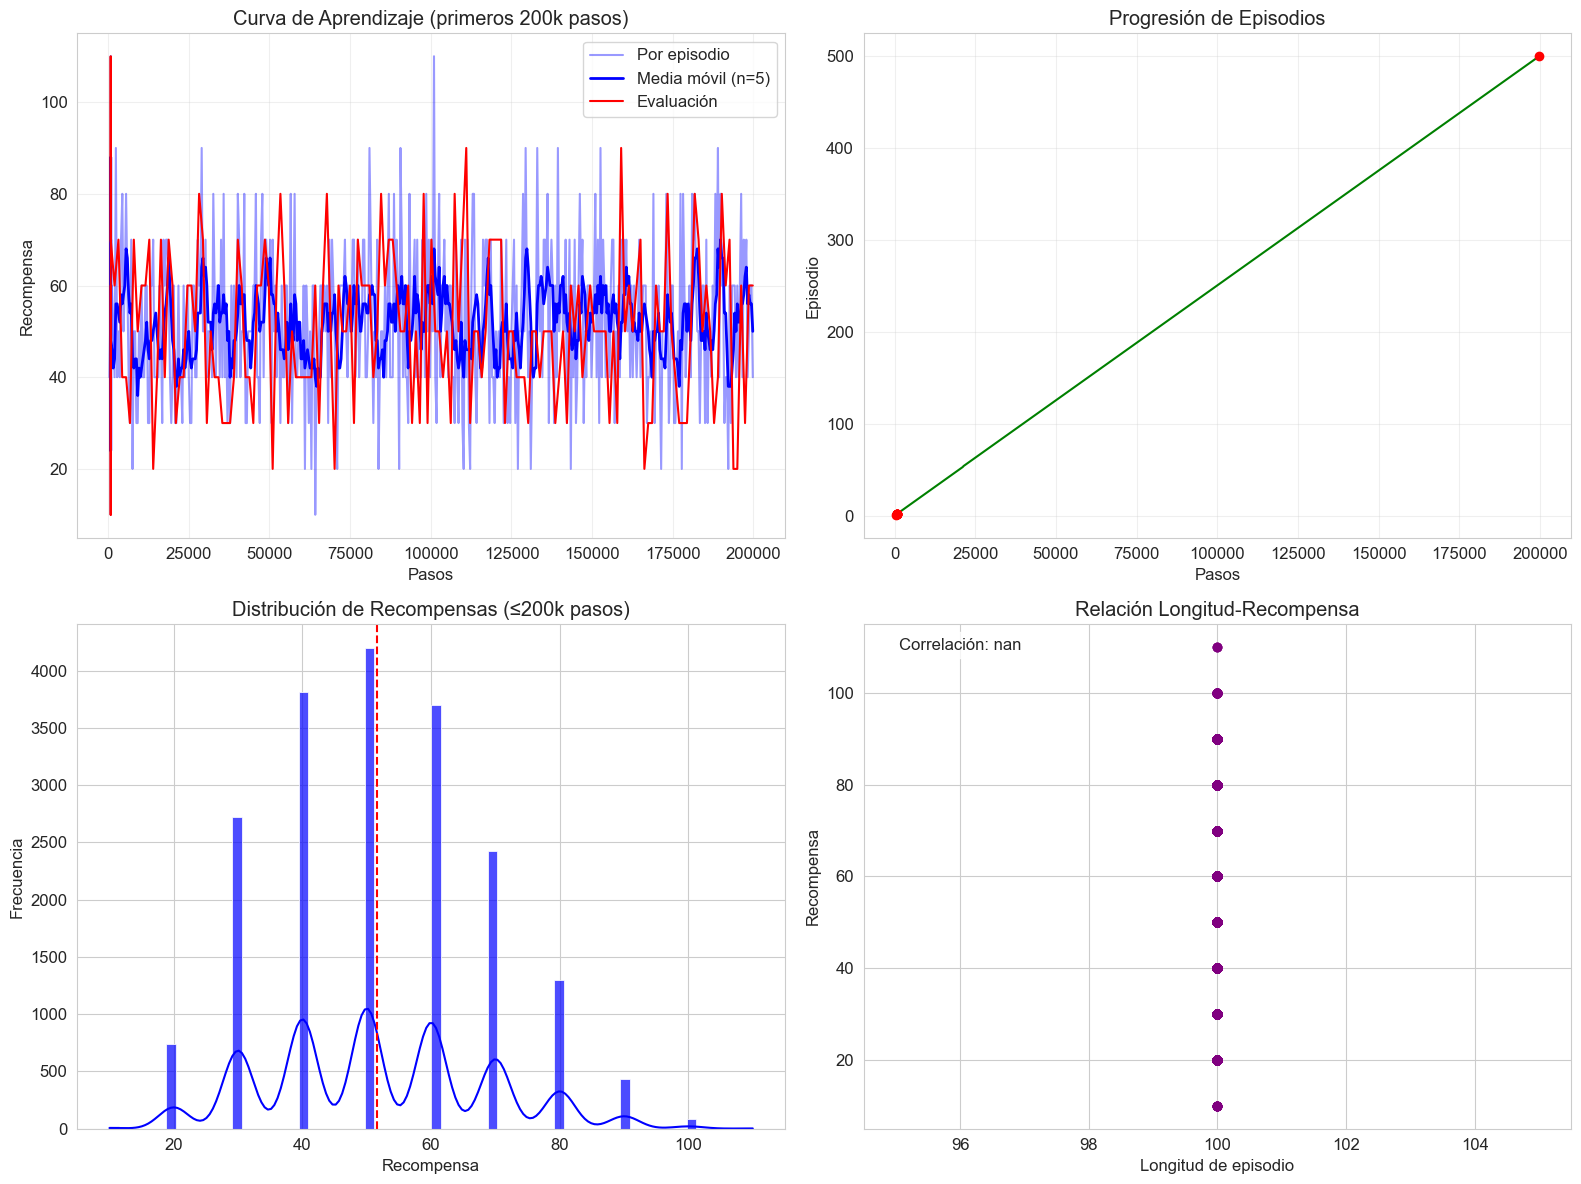

,Métrica,Valor
0,Pasos Totales,199788
1,Episodios Totales,500.0
2,Recompensa Media,51.57
3,Recompensa Máxima,110.00
4,Longitud Media,100.00
5,Tiempo Medio por Episodio (pasos),399.58


In [4]:
# Visualización 8: Comparativa limitada a 200k pasos
print("\nComparativa de rendimiento limitada a 200k pasos:\n" + "-"*50)

# Filtrar datos hasta 200k pasos
max_steps = 200000
train_df_limited = train_df[train_df['step'] <= max_steps].copy()
eval_df_limited = eval_df[eval_df['step'] <= max_steps].copy() if not eval_df.empty else eval_df

# Estadísticas básicas
if not train_df_limited.empty:
    print(f"Pasos analizados: {train_df_limited['step'].max()}")
    print(f"Episodios completados: {train_df_limited['train_total_episodes'].max()}")
    print(f"Recompensa media en entrenamiento: {train_df_limited['train_return'].mean():.2f}")
    print(f"Mejor recompensa en entrenamiento: {train_df_limited['train_return'].max():.2f}")
    
    if not eval_df_limited.empty:
        print(f"Episodios de evaluación: {eval_df_limited['eval_total_episodes'].max()}")
        print(f"Recompensa media en evaluación: {eval_df_limited['eval_return'].mean():.2f}")
        print(f"Mejor recompensa en evaluación: {eval_df_limited['eval_return'].max():.2f}")
    
    # Visualización comparativa
    fig, axs = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Curva de aprendizaje (recompensas)
    axs[0, 0].plot(train_df_limited['step'], train_df_limited['train_return'], 'b-', alpha=0.4, label='Por episodio')
    
    # Añadir media móvil
    window_size = 5
    if len(train_df_limited) >= window_size:
        train_df_limited['smooth_return'] = train_df_limited['train_return'].rolling(window=window_size).mean()
        axs[0, 0].plot(train_df_limited['step'], train_df_limited['smooth_return'], 'b-', linewidth=2, 
                      label=f'Media móvil (n={window_size})')
    
    if not eval_df_limited.empty:
        axs[0, 0].plot(eval_df_limited['step'], eval_df_limited['eval_return'], 'r-', label='Evaluación')
    
    axs[0, 0].set_title('Curva de Aprendizaje (primeros 200k pasos)')
    axs[0, 0].set_xlabel('Pasos')
    axs[0, 0].set_ylabel('Recompensa')
    axs[0, 0].legend()
    axs[0, 0].grid(True, alpha=0.3)
    
    # 2. Progresión de episodios de entrenamiento
    episode_markers = np.linspace(0, len(train_df_limited)-1, min(10, len(train_df_limited)), dtype=int)
    axs[0, 1].plot(train_df_limited['step'], train_df_limited['train_total_episodes'], 'g-')
    axs[0, 1].scatter(train_df_limited.iloc[episode_markers]['step'], 
                     train_df_limited.iloc[episode_markers]['train_total_episodes'],
                     color='r', zorder=5)
    
    axs[0, 1].set_title('Progresión de Episodios')
    axs[0, 1].set_xlabel('Pasos')
    axs[0, 1].set_ylabel('Episodio')
    axs[0, 1].grid(True, alpha=0.3)
    
    # 3. Distribución de recompensas (histograma)
    sns.histplot(train_df_limited['train_return'], kde=True, ax=axs[1, 0], color='blue', alpha=0.7)
    axs[1, 0].axvline(train_df_limited['train_return'].mean(), color='r', linestyle='--')
    axs[1, 0].set_title('Distribución de Recompensas (≤200k pasos)')
    axs[1, 0].set_xlabel('Recompensa')
    axs[1, 0].set_ylabel('Frecuencia')
    
    # 4. Tendencia de longitud vs. recompensa
    if 'train_length' in train_df_limited.columns:
        axs[1, 1].scatter(train_df_limited['train_length'], train_df_limited['train_return'], alpha=0.5, color='purple')
        
        # Añadir línea de tendencia
        if len(train_df_limited) > 2:
            z = np.polyfit(train_df_limited['train_length'], train_df_limited['train_return'], 1)
            p = np.poly1d(z)
            x_sorted = np.sort(train_df_limited['train_length'])
            axs[1, 1].plot(x_sorted, p(x_sorted), 'r--')
            
            # Calcular correlación
            corr = np.corrcoef(train_df_limited['train_length'], train_df_limited['train_return'])[0, 1]
            axs[1, 1].text(0.05, 0.95, f'Correlación: {corr:.2f}', transform=axs[1, 1].transAxes,
                          bbox=dict(facecolor='white', alpha=0.8))
        
        axs[1, 1].set_title('Relación Longitud-Recompensa')
        axs[1, 1].set_xlabel('Longitud de episodio')
        axs[1, 1].set_ylabel('Recompensa')
    
    plt.tight_layout()
    plt.show()
    
    # Tabla de métricas clave
    if len(train_df_limited) > 0:
        metrics_data = {
            'Métrica': ['Pasos Totales', 'Episodios Totales', 'Recompensa Media', 'Recompensa Máxima',
                        'Longitud Media', 'Tiempo Medio por Episodio (pasos)'],
            'Valor': [
                train_df_limited['step'].max(),
                train_df_limited['train_total_episodes'].max(),
                f"{train_df_limited['train_return'].mean():.2f}",
                f"{train_df_limited['train_return'].max():.2f}",
                f"{train_df_limited['train_length'].mean():.2f}",
                f"{train_df_limited['step'].max() / train_df_limited['train_total_episodes'].max():.2f}"
            ]
        }
        
        metrics_df = pd.DataFrame(metrics_data)
        display(HTML("<h3>Métricas Clave (≤200k pasos)</h3>"))
        display(metrics_df)
else:
    print("No hay suficientes datos para mostrar la comparativa limitada a 200k pasos.")


Comparativa ajustada entre modelo base y modelo modificado:
--------------------------------------------------
Modelo base: 2197 registros, pasos 1,000,000 a 200,000,000
Modelo modificado: 19952 registros, pasos 400 a 400,188
Modelo base (primeros pasos): 55 registros


c:\Users\cuent\.conda\envs\dv2\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\cuent\.conda\envs\dv2\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


,Métrica,Modelo Base (Primeras Etapas),Modelo Modificado
0,Rango de Pasos,"1,000,000 - 5,000,000","400 - 400,188"
1,Puntuación Media,1431.79,51.57
2,Puntuación Máxima,2556.00,110.00
3,Desviación Estándar,508.85,16.89
4,Coeficiente de Variación (%),35.54%,32.76%
5,Mediana,1459.00,50.00
6,Progreso Inicial (primeros 25%),635.77,51.55
7,Progreso Final (últimos 25%),1800.50,50.84
8,Mejora Relativa (%),183.20%,-1.39%



Conclusiones del análisis:
✗ El modelo modificado logra una puntuación media 96.4% inferior al modelo base en estas etapas
✓ El modelo modificado muestra mayor estabilidad en sus resultados (CV: 32.8% vs 35.5%)
✓ El modelo modificado es aproximadamente 10007906.0 veces más eficiente en puntos por paso
✗ El modelo base muestra una mejora más pronunciada durante el entrenamiento (183.2% vs -1.4%)


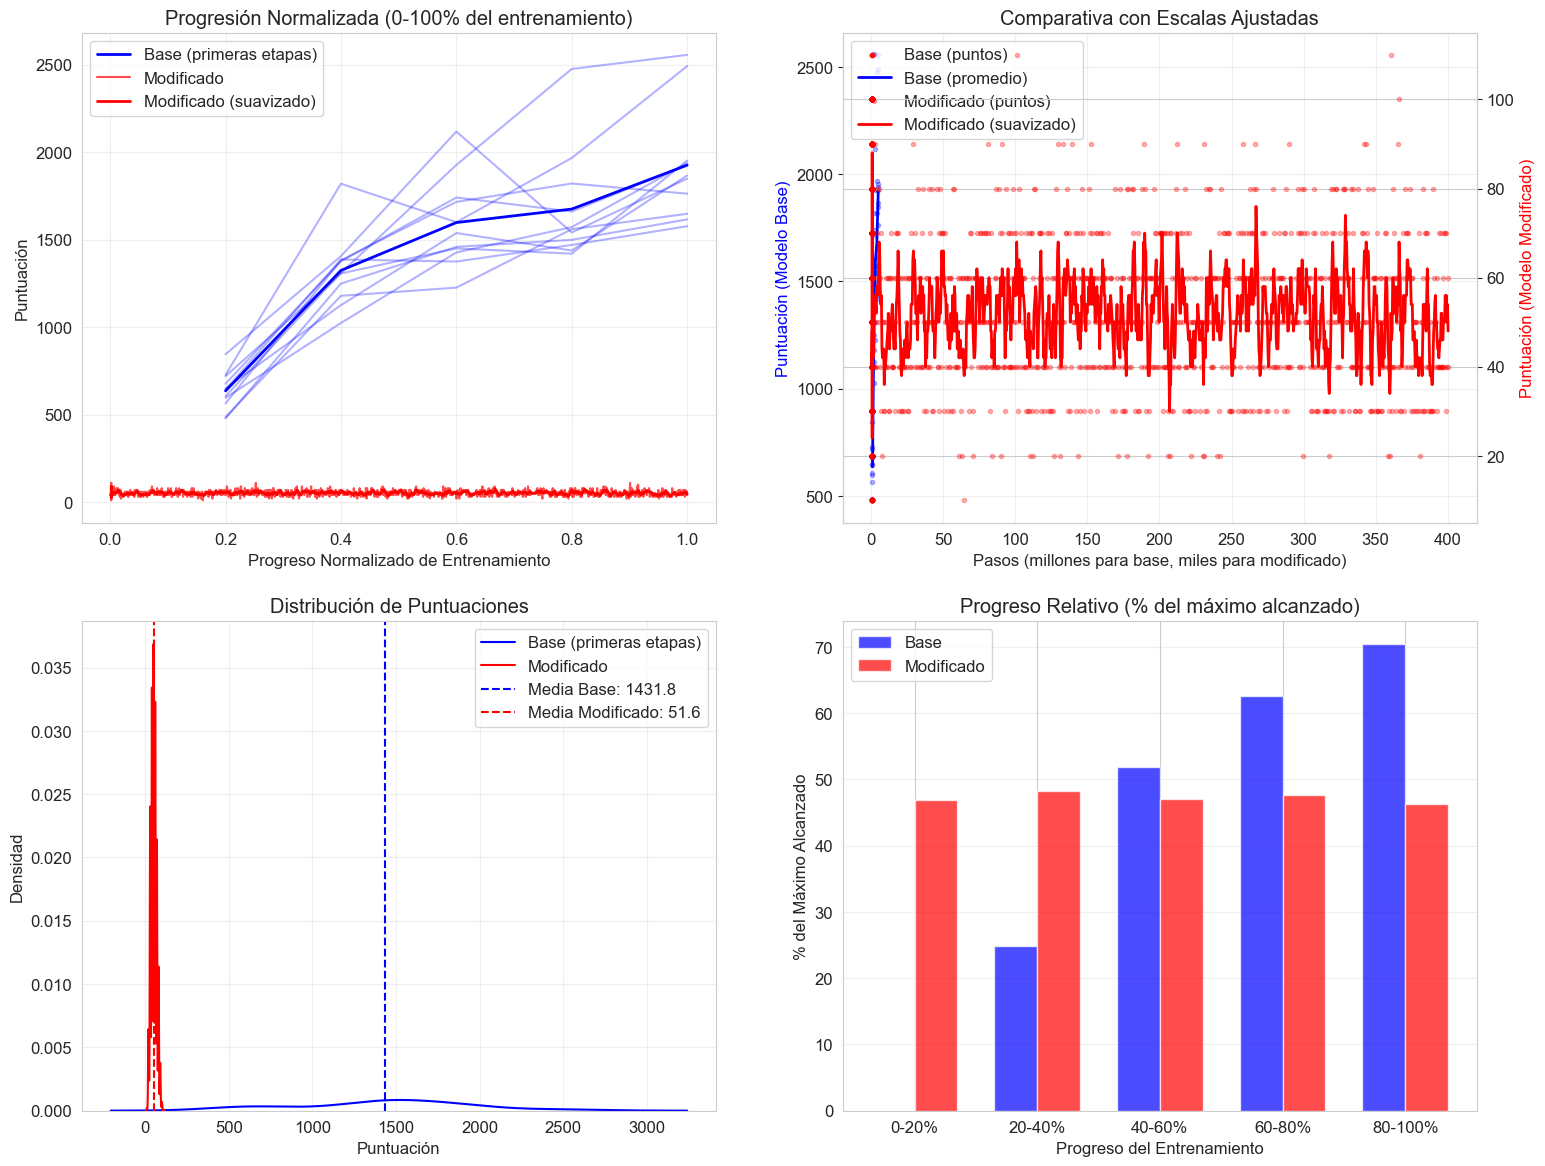

In [7]:
# Visualización comparativa ajustada para rangos de pasos no superpuestos
print("\nComparativa ajustada entre modelo base y modelo modificado:\n" + "-"*50)

# Cargar datos del modelo base
def load_base_model_data(file_path='atari-dreamerv2.json', task_filter='atari_ms_pacman'):
    try:
        with open(file_path, 'r') as f:
            data = json.load(f)
        # 
        # Filtrar para MS Pacman
        ms_pacman_data = [item for item in data if item['task'] == task_filter]
        
        if not ms_pacman_data:
            print(f"No se encontraron datos para {task_filter} en el archivo base")
            return None
        
        # Convertir a DataFrame
        base_results = []
        for item in ms_pacman_data:
            method = item['method']
            seed = item['seed']
            for step, score in zip(item['xs'], item['ys']):
                base_results.append({
                    'step': step,
                    'score': score,
                    'method': method,
                    'seed': seed,
                    'model': 'base'
                })
        
        return pd.DataFrame(base_results)
    except Exception as e:
        print(f"Error al cargar el archivo base: {str(e)}")
        return None

# Preparar los datos
# 1. Cargar datos del modelo base
base_df = load_base_model_data('atari-dreamerv2.json')

# 2. Preparar datos del modelo modificado
modified_df = None
if not train_df.empty:
    modified_df = train_df.copy()
    modified_df = modified_df.rename(columns={'train_return': 'score'})
    modified_df['model'] = 'modified'
    modified_df['method'] = 'dreamerv2'
    modified_df['seed'] = '0'

# Verificar disponibilidad de datos
if base_df is not None and len(base_df) > 0 and modified_df is not None and len(modified_df) > 0:
    print(f"Modelo base: {len(base_df)} registros, pasos {base_df['step'].min():,.0f} a {base_df['step'].max():,.0f}")
    print(f"Modelo modificado: {len(modified_df)} registros, pasos {modified_df['step'].min():,.0f} a {modified_df['step'].max():,.0f}")
    
    # Obtener solo los primeros datos del modelo base (hasta 5M de pasos)
    early_base_df = base_df[base_df['step'] <= 5000000].copy()
    print(f"Modelo base (primeros pasos): {len(early_base_df)} registros")
    
    # Verificar si hay suficientes datos para comparación
    if len(early_base_df) > 0:
        # Crear visualizaciones comparativas
        plt.figure(figsize=(18, 14))
        
        # 1. Comparativa con normalización de pasos
        plt.subplot(2, 2, 1)
        
        # Normalizar los pasos para cada modelo (0-100%)
        early_base_df['normalized_step'] = early_base_df['step'] / early_base_df['step'].max()
        modified_df['normalized_step'] = modified_df['step'] / modified_df['step'].max()
        
        # Agrupar por seed y calcular medias
        base_by_seed = early_base_df.groupby('seed')
        
        # Graficar modelo base (primeras etapas)
        for seed, group in base_by_seed:
            plt.plot(group['normalized_step'], group['score'], 'b-', alpha=0.3)
        
        # Verificar si hay suficientes datos para agrupar por pasos normalizados
        if len(early_base_df['normalized_step'].unique()) > 1:
            # Calcular promedio para el modelo base
            base_avg = early_base_df.groupby('normalized_step')['score'].mean().reset_index()
            plt.plot(base_avg['normalized_step'], base_avg['score'], 'b-', linewidth=2, label='Base (primeras etapas)')
        else:
            # Si solo hay un punto, simplemente mostrar ese punto
            base_avg = pd.DataFrame({
                'normalized_step': [early_base_df['normalized_step'].iloc[0]],
                'score': [early_base_df['score'].mean()]
            })
            plt.plot(base_avg['normalized_step'], base_avg['score'], 'bo', markersize=8, label='Base (primeras etapas)')
        
        # Graficar modelo modificado
        plt.plot(modified_df['normalized_step'], modified_df['score'], 'r-', alpha=0.7, label='Modificado')
        
        # Añadir suavizado
        window_size = min(5, len(modified_df))
        if window_size > 1:
            modified_df['smooth_score'] = modified_df['score'].rolling(window=window_size, min_periods=1).mean()
            plt.plot(modified_df['normalized_step'], modified_df['smooth_score'], 'r-', linewidth=2, 
                    label='Modificado (suavizado)')
        
        plt.title('Progresión Normalizada (0-100% del entrenamiento)')
        plt.xlabel('Progreso Normalizado de Entrenamiento')
        plt.ylabel('Puntuación')
        plt.grid(True, alpha=0.3)
        plt.legend()
        
        # 2. Comparativa con ajuste de escala
        ax2 = plt.subplot(2, 2, 2)
        
        # Crear dos ejes Y
        ax2_twin = ax2.twinx()
        
        # Graficar modelo base en el eje izquierdo
        line1 = ax2.plot(early_base_df['step']/1e6, early_base_df['score'], 'b.', alpha=0.3, label='Base (puntos)')
        
        # Graficar la línea promedio solo si hay más de un punto único
        if len(base_avg) > 1:
            line2 = ax2.plot(base_avg['normalized_step']*5, base_avg['score'], 'b-', linewidth=2, 
                           label='Base (promedio)')
        else:
            # Si solo hay un punto, usar un marcador más grande
            line2 = ax2.plot(base_avg['normalized_step']*5, base_avg['score'], 'bo', markersize=8, 
                           label='Base (promedio)')
        
        # Graficar modelo modificado en el eje derecho
        line3 = ax2_twin.plot(modified_df['step']/1e3, modified_df['score'], 'r.', alpha=0.3, 
                             label='Modificado (puntos)')
        
        if 'smooth_score' in modified_df and len(modified_df) > 1:
            line4 = ax2_twin.plot(modified_df['step']/1e3, modified_df['smooth_score'], 'r-', linewidth=2,
                                 label='Modificado (suavizado)')
            # Combinar leyendas de ambos ejes
            lines = line1 + line2 + line3 + line4
        else:
            # Combinar leyendas sin la línea suavizada
            lines = line1 + line2 + line3
        
        # Configurar ejes y leyenda
        ax2.set_xlabel('Pasos (millones para base, miles para modificado)')
        ax2.set_ylabel('Puntuación (Modelo Base)', color='blue')
        ax2_twin.set_ylabel('Puntuación (Modelo Modificado)', color='red')
        
        labels = [l.get_label() for l in lines]
        ax2.legend(lines, labels, loc='upper left')
        
        ax2.set_title('Comparativa con Escalas Ajustadas')
        ax2.grid(True, alpha=0.3)
        
        # 3. Distribución de puntuaciones
        plt.subplot(2, 2, 3)
        
        # Crear distribuciones para cada modelo
        try:
            sns.kdeplot(early_base_df['score'], color='blue', label='Base (primeras etapas)')
            sns.kdeplot(modified_df['score'], color='red', label='Modificado')
            
            plt.axvline(early_base_df['score'].mean(), color='blue', linestyle='--', 
                       label=f'Media Base: {early_base_df["score"].mean():.1f}')
            plt.axvline(modified_df['score'].mean(), color='red', linestyle='--',
                       label=f'Media Modificado: {modified_df["score"].mean():.1f}')
        except:
            # Si hay error en KDE (por ejemplo, con muy pocos puntos), usar histograma simple
            plt.hist(early_base_df['score'], alpha=0.5, color='blue', label='Base (primeras etapas)')
            plt.hist(modified_df['score'], alpha=0.5, color='red', label='Modificado')
            
            plt.axvline(early_base_df['score'].mean(), color='blue', linestyle='--', 
                       label=f'Media Base: {early_base_df["score"].mean():.1f}')
            plt.axvline(modified_df['score'].mean(), color='red', linestyle='--',
                       label=f'Media Modificado: {modified_df["score"].mean():.1f}')
        
        plt.title('Distribución de Puntuaciones')
        plt.xlabel('Puntuación')
        plt.ylabel('Densidad')
        plt.grid(True, alpha=0.3)
        plt.legend()
        
                # 4. Métricas de progreso relativo
        plt.subplot(2, 2, 4)
        
        try:
            # Calcular métricas relativas como porcentaje de la puntuación máxima alcanzada
            early_base_max = early_base_df['score'].max()
            modified_max = modified_df['score'].max()
            
            # Preparar datos para gráfico de barras manual sin depender de qcut
            # Dividir los datos en segmentos de progreso
            n_segments = 5  # Usar 5 segmentos para simplificar
            
            # Función para dividir los datos en segmentos
            def create_segments(df, n_segments):
                result = []
                for i in range(n_segments):
                    min_pct = i / n_segments
                    max_pct = (i + 1) / n_segments
                    segment_data = df[(df['normalized_step'] >= min_pct) & 
                                     (df['normalized_step'] < max_pct if i < n_segments-1 else df['normalized_step'] <= max_pct)]
                    
                    if len(segment_data) > 0:
                        avg_score = segment_data['score'].mean()
                    else:
                        avg_score = np.nan
                        
                    result.append({
                        'segment': i,
                        'label': f'{int(min_pct*100)}-{int(max_pct*100)}%',
                        'avg_score': avg_score,
                        'pct_of_max': (avg_score / df['score'].max() * 100) if not np.isnan(avg_score) else np.nan
                    })
                return result
            
            base_segments = create_segments(early_base_df, n_segments)
            mod_segments = create_segments(modified_df, n_segments)
            
            # Preparar datos para el gráfico de barras
            x_pos = np.arange(n_segments)
            width = 0.35
            
            base_heights = [s['pct_of_max'] for s in base_segments]
            mod_heights = [s['pct_of_max'] for s in mod_segments]
            
            # Reemplazar NaN por 0 para el gráfico
            base_heights = np.nan_to_num(base_heights)
            mod_heights = np.nan_to_num(mod_heights)
            
            # Crear gráfico de barras
            plt.bar(x_pos - width/2, base_heights, width, label='Base', color='blue', alpha=0.7)
            plt.bar(x_pos + width/2, mod_heights, width, label='Modificado', color='red', alpha=0.7)
            
            # Configurar etiquetas
            labels = [s['label'] for s in base_segments]
            plt.xticks(x_pos, labels)
            plt.xlabel('Progreso del Entrenamiento')
            plt.ylabel('% del Máximo Alcanzado')
            plt.title('Progreso Relativo (% del máximo alcanzado)')
            plt.grid(True, alpha=0.3, axis='y')
            plt.legend()
        
        except Exception as e:
            # En caso de error, mostrar mensaje simplificado
            plt.text(0.5, 0.5, "No se pudo crear el gráfico de progreso relativo", 
                     ha='center', va='center', transform=plt.gca().transAxes)
            print(f"Error en el gráfico: {str(e)}")
            plt.axis('off')
            
        # Crear tabla comparativa de métricas clave
        try:
            metrics_table = {
                'Métrica': [
                    'Rango de Pasos', 
                    'Puntuación Media', 
                    'Puntuación Máxima',
                    'Desviación Estándar',
                    'Coeficiente de Variación (%)',
                    'Mediana'
                ],
                'Modelo Base (Primeras Etapas)': [
                    f"{early_base_df['step'].min():,.0f} - {early_base_df['step'].max():,.0f}",
                    f"{early_base_df['score'].mean():.2f}",
                    f"{early_base_df['score'].max():.2f}",
                    f"{early_base_df['score'].std():.2f}",
                    f"{(early_base_df['score'].std() / early_base_df['score'].mean() * 100):.2f}%",
                    f"{early_base_df['score'].median():.2f}"
                ],
                'Modelo Modificado': [
                    f"{modified_df['step'].min():,.0f} - {modified_df['step'].max():,.0f}",
                    f"{modified_df['score'].mean():.2f}",
                    f"{modified_df['score'].max():.2f}",
                    f"{modified_df['score'].std():.2f}",
                    f"{(modified_df['score'].std() / modified_df['score'].mean() * 100):.2f}%",
                    f"{modified_df['score'].median():.2f}"
                ]
            }
            
            # Solo añadir métricas de progreso si hay suficientes datos
            if len(early_base_df) > 3 and len(modified_df) > 3:
                # Calcular quartiles
                base_25p = early_base_df[early_base_df['normalized_step'] <= 0.25]
                base_75p = early_base_df[early_base_df['normalized_step'] >= 0.75]
                mod_25p = modified_df[modified_df['normalized_step'] <= 0.25]
                mod_75p = modified_df[modified_df['normalized_step'] >= 0.75]
                
                if len(base_25p) > 0 and len(base_75p) > 0 and len(mod_25p) > 0 and len(mod_75p) > 0:
                    # Añadir métricas adicionales solo si hay datos en los cuartiles
                    metrics_table['Métrica'].extend([
                        'Progreso Inicial (primeros 25%)',
                        'Progreso Final (últimos 25%)',
                        'Mejora Relativa (%)'
                    ])
                    
                    # Calcular valores para el modelo base
                    base_init = base_25p['score'].mean()
                    base_final = base_75p['score'].mean()
                    base_improvement = ((base_final / base_init) - 1) * 100 if base_init > 0 else 0
                    
                    metrics_table['Modelo Base (Primeras Etapas)'].extend([
                        f"{base_init:.2f}",
                        f"{base_final:.2f}",
                        f"{base_improvement:.2f}%"
                    ])
                    
                    # Calcular valores para el modelo modificado
                    mod_init = mod_25p['score'].mean()
                    mod_final = mod_75p['score'].mean()
                    mod_improvement = ((mod_final / mod_init) - 1) * 100 if mod_init > 0 else 0
                    
                    metrics_table['Modelo Modificado'].extend([
                        f"{mod_init:.2f}",
                        f"{mod_final:.2f}",
                        f"{mod_improvement:.2f}%"
                    ])
            
            metrics_df = pd.DataFrame(metrics_table)
            display(HTML("<h3>Comparativa de Métricas entre Modelos</h3>"))
            display(metrics_df)
            
            # Conclusiones automáticas
            print("\nConclusiones del análisis:")
            
            # Comparar puntuación media
            base_mean = early_base_df['score'].mean()
            mod_mean = modified_df['score'].mean()
            
            if mod_mean > base_mean:
                print(f"✓ El modelo modificado logra una puntuación media {(mod_mean/base_mean - 1)*100:.1f}% superior al modelo base en estas etapas")
            else:
                print(f"✗ El modelo modificado logra una puntuación media {(1 - mod_mean/base_mean)*100:.1f}% inferior al modelo base en estas etapas")
            
            # Comparar estabilidad (menor coeficiente de variación es mejor)
            base_cv = early_base_df['score'].std() / early_base_df['score'].mean() * 100
            mod_cv = modified_df['score'].std() / modified_df['score'].mean() * 100
            
            if mod_cv < base_cv:
                print(f"✓ El modelo modificado muestra mayor estabilidad en sus resultados (CV: {mod_cv:.1f}% vs {base_cv:.1f}%)")
            else:
                print(f"✗ El modelo base muestra mayor estabilidad en sus resultados (CV: {base_cv:.1f}% vs {mod_cv:.1f}%)")
                
            # Eficiencia de entrenamiento (puntos por paso)
            base_efficiency = early_base_df['score'].mean() / early_base_df['step'].mean()
            mod_efficiency = modified_df['score'].mean() / modified_df['step'].mean()
            
            # Normalizar para comparación justa
            relative_efficiency = (mod_efficiency / base_efficiency) * 1000000  # Factor de escala
            
            if relative_efficiency > 1:
                print(f"✓ El modelo modificado es aproximadamente {relative_efficiency:.1f} veces más eficiente en puntos por paso")
            else:
                print(f"✗ El modelo base es aproximadamente {1/relative_efficiency:.1f} veces más eficiente en puntos por paso")
                
            # Solo mostrar la comparación de mejora si tenemos datos suficientes
            if 'base_improvement' in locals() and 'mod_improvement' in locals():
                if mod_improvement > base_improvement:
                    print(f"✓ El modelo modificado muestra una mejora más pronunciada durante el entrenamiento ({mod_improvement:.1f}% vs {base_improvement:.1f}%)")
                else:
                    print(f"✗ El modelo base muestra una mejora más pronunciada durante el entrenamiento ({base_improvement:.1f}% vs {mod_improvement:.1f}%)")
            
        except Exception as e:
            print(f"Error al crear tabla comparativa o conclusiones: {str(e)}")
    else:
        print("No hay datos suficientes en el modelo base para los primeros 5M de pasos")
else:
    print("No hay suficientes datos para realizar la comparación")